# Алгоритмы кластеризации

## Функция для отображения изображения

In [1]:
import matplotlib.pyplot as plt
import cv2
import skimage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

def draw_picture(image, title, bgr=True):
    if bgr:
        b, g, r = cv2.split(image)
        image = cv2.merge([r, g, b])

    plt.figure(figsize=(7, 5))
    plt.axis('off')
    plt.imshow(image)
    plt.title(title)
    plt.show()

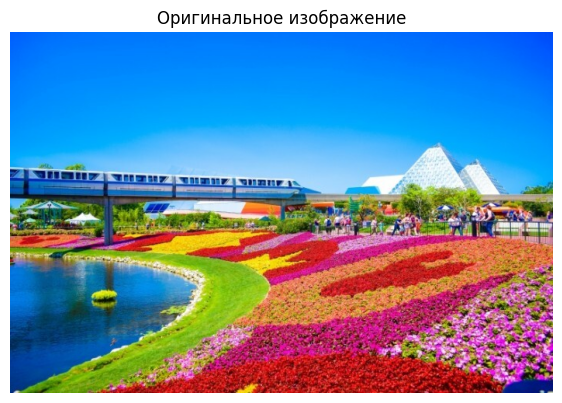

In [2]:
img = cv2.imread('feml.jpg')
draw_picture(img, 'Оригинальное изображение', bgr=True)

## Алгоритмы кластеризации

### K-means

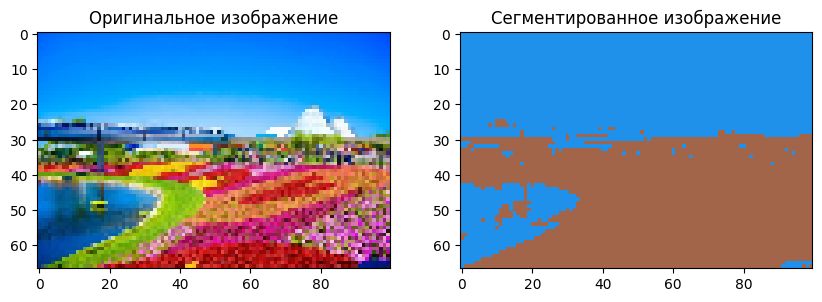

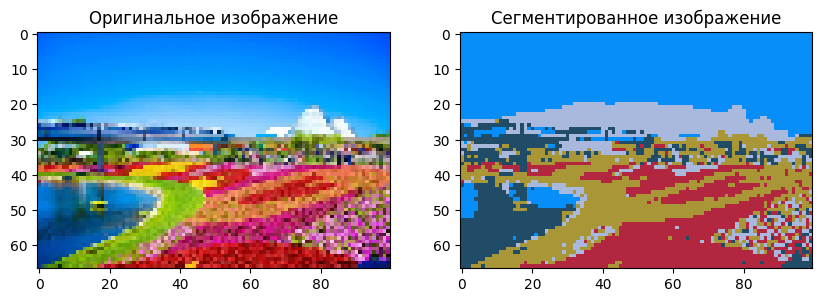

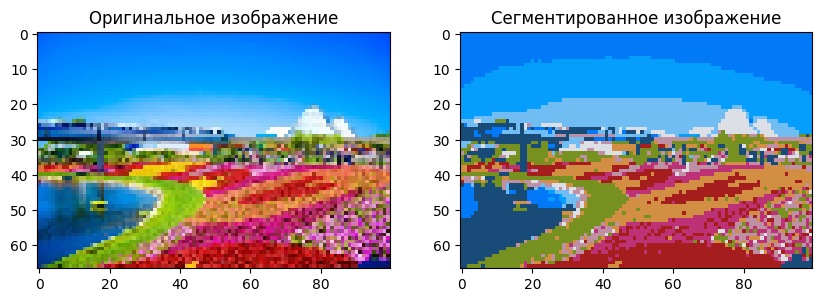

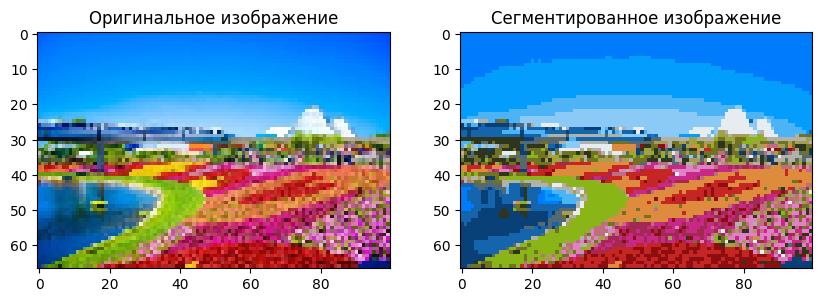

In [4]:
from skimage.metrics import structural_similarity as ssim

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# уменьшаю размер изображения, потому что иначе ноутбук падает при попытке использования алгоритма AgglomerativeClustering.
img_small = cv2.resize(img_rgb, (100, 67))

# Получите размеры изображения
height, width, channels = img_small.shape

# Преобразуйте изображение в двумерный массив (число пикселей x число каналов)
img_reshaped = img_small.reshape((-1, 3))

ssim_kmean_val = []

def kmeans_with_clusters(nClus):
    kmeans = KMeans(n_clusters=nClus, random_state=0).fit(img_reshaped)

    labels = kmeans.labels_

    centers_rgb = kmeans.cluster_centers_
    segmented_img = centers_rgb[labels].reshape(height, width, 3)
    segmented_img = segmented_img.clip(0, 255).astype('uint8')

    ssim_kmean = ssim(img_small, segmented_img, channel_axis=2, data_range=255)
    ssim_kmean_val.append(ssim_kmean)

    plt.figure(figsize=(10, 5))

    # Оригинальное изображение
    plt.subplot(1, 2, 1)
    plt.title('Оригинальное изображение')
    plt.imshow(img_small)

    # Сегментированное изображение
    plt.subplot(1, 2, 2)
    plt.title('Сегментированное изображение')
    plt.imshow(segmented_img)

kmeans_with_clusters(2)
kmeans_with_clusters(5)
kmeans_with_clusters(10)
kmeans_with_clusters(20)
plt.show()

In [5]:
ssim_kmean_val

[np.float64(0.28092995471452437),
 np.float64(0.575140047156121),
 np.float64(0.7305477643929116),
 np.float64(0.8495594659764603)]

С увеличением количества кластеров в модели улучшается и метрика SSIM.

### DBSCAN

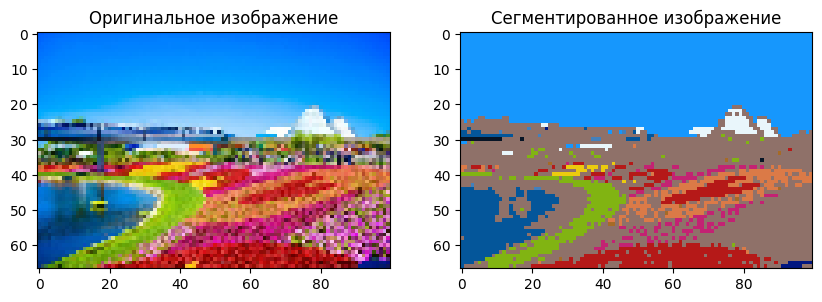

In [20]:
import numpy as np

dbscan = DBSCAN(eps=10, min_samples=10).fit(img_reshaped)

labels = dbscan.labels_

segmented_img_dbscan = np.zeros_like(img_small)

for label in np.unique(labels):
    mask = labels.reshape(height, width) == label
    mean_color = img_small[mask].mean(axis=0)
    segmented_img_dbscan[mask] = mean_color


segmented_img_dbscan = segmented_img_dbscan.clip(0, 255).astype('uint8')

ssim_dbscan = ssim(img_small, segmented_img_dbscan, channel_axis=2, data_range=255)

plt.figure(figsize=(10, 5))

# Оригинальное изображение
plt.subplot(1, 2, 1)
plt.title('Оригинальное изображение')
plt.imshow(img_small)

# Сегментированное изображение
plt.subplot(1, 2, 2)
plt.title('Сегментированное изображение')
plt.imshow(segmented_img_dbscan)

In [21]:
ssim_dbscan

np.float64(0.4352305981532729)

Параметры модели были подобраны подгоном.

### AgglomerativeClustering

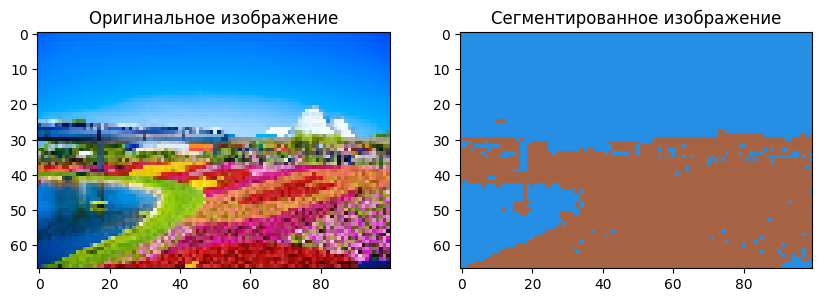

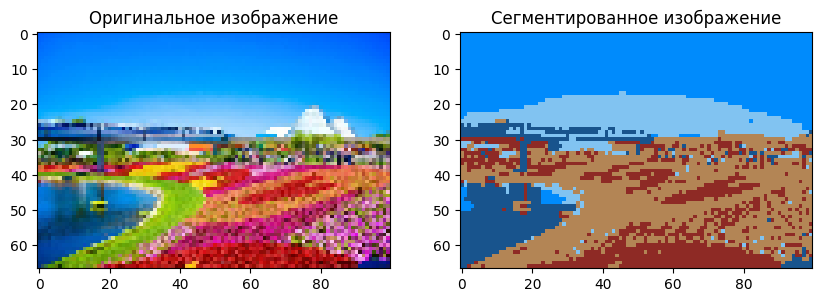

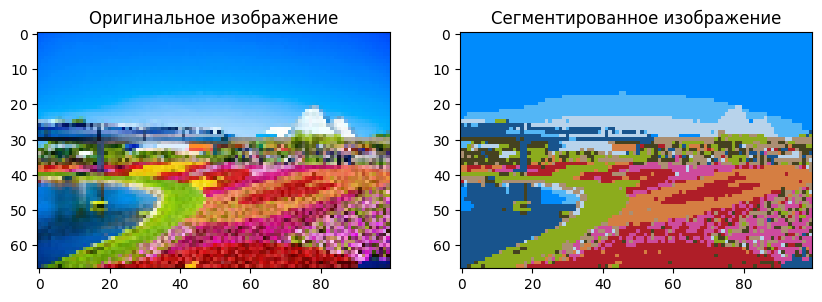

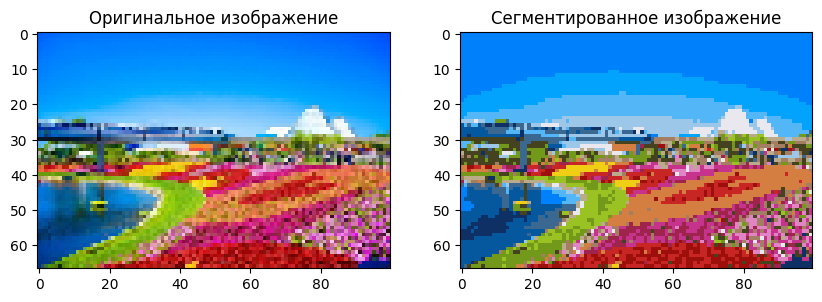

In [10]:
ssim_agg_val = []

def agg_with_clusters(nClus):
    agg = AgglomerativeClustering(n_clusters=nClus).fit(img_reshaped)

    labels = agg.labels_

    segmented_img = np.zeros_like(img_small)

    for label in np.unique(labels):
        mask = labels.reshape(height, width) == label
        mean_color = img_small[mask].mean(axis=0)
        segmented_img[mask] = mean_color

    segmented_img = segmented_img.clip(0, 255).astype('uint8')

    ssim_agg = ssim(img_small, segmented_img, channel_axis=2, data_range=255)
    ssim_agg_val.append(ssim_agg)

    plt.figure(figsize=(10, 5))

    # Оригинальное изображение
    plt.subplot(1, 2, 1)
    plt.title('Оригинальное изображение')
    plt.imshow(img_small)

    # Сегментированное изображение
    plt.subplot(1, 2, 2)
    plt.title('Сегментированное изображение')
    plt.imshow(segmented_img)

agg_with_clusters(2)
agg_with_clusters(5)
agg_with_clusters(10)
agg_with_clusters(20)
plt.show()

In [11]:
ssim_agg_val

[np.float64(0.28427919996764),
 np.float64(0.6188192715298156),
 np.float64(0.7672272584615308),
 np.float64(0.8473391460817922)]

Для данного алгоритма также видно, что с увеичением кластеров растет и схожесть с оригиналом.

# Вывод

In [22]:
results = {
    'KMeans 20': ssim_kmean_val[-1],
    'Agglomerative 20': ssim_agg_val[-1],
    'DBSCAN': ssim_dbscan
}
results

{'KMeans 20': np.float64(0.8495594659764603),
 'Agglomerative 20': np.float64(0.8473391460817922),
 'DBSCAN': np.float64(0.4352305981532729)}

По значениям метрики SSIM видно, что при увеличении количества кластеров качество восстановления изображения растёт как у KMeans, так и у AgglomerativeClustering. При 20 кластерах KMeans показал SSIM = 0.8496, а AgglomerativeClustering — SSIM = 0.8473. Эти значения почти одинаковые, но KMeans оказался немного лучше.

DBSCAN дал SSIM = 0.43. Возможно, для улучшения показателя необходимо подбирать другие параметры алгоритма, либо проводить дополнительную обработку изображения.

Таким образом, среди корректно сравнимых моделей лучший результат показал KMeans с 20 кластерами. Он даёт наибольшее значение SSIM и при этом работает быстрее и устойчивее, чем AgglomerativeClustering.